# 01 — Exploratory Data Analysis
**NGAFID — Cessna 172 Fleet Aviation Health Diagnosis**

CS3315 · Naval Postgraduate School · MSCS Q3 2026

---

**Dataset:** 11,446 Cessna-172 flights · 23 sensors @ 1 Hz · 19 fault classes  
**Repr A:** Raw interpolated time-series — `(11446, 23, 2048)` float32  
**Goal:** Understand data structure, class imbalance, sensor dynamics, and the three core challenges:
1. *Target component sparsity* — fault signal buried in low-variance PCs
2. *Multi-task coupling* — flight phases create heterogeneous sub-distributions
3. *Dual imbalance* — 38:1 AD ratio, extreme long-tail in FC

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import sys, json, pickle, warnings
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── IEEE figure style ───────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.grid': True, 'grid.alpha': 0.3,
})
NPS_BLUE = '#003087'
NPS_GOLD = '#B8960C'

# ── Paths ───────────────────────────────────────────────────────────────────
ROOT   = Path('data')
DATA   = ROOT
OUT    = ROOT
CACHE  = ROOT
FIGS   = Path('figures')
FIGS.mkdir(exist_ok=True)

print('Paths OK:', ROOT.exists(), DATA.exists(), CACHE.exists())

Paths OK: True True True


In [2]:
# ── Load data ───────────────────────────────────────────────────────────────
hdr  = pd.read_csv(DATA / 'flight_header.csv')
stats_df = pd.read_csv(DATA / 'stats.csv', index_col=0)

with open(DATA / 'flight_data.pkl', 'rb') as f:
    raw_flights = pickle.load(f)          # dict: {master_idx: np.array(T, 23)}

with open(OUT / 'fault_mapping.json') as f:
    fault_map = json.load(f)

X_raw = np.load(CACHE / 'X_raw_L2048.npy')   # (11446, 23, 2048) float32

SENSORS = [c for c in stats_df.columns if c not in ('timestep', 'cluster')]
SENSOR_GROUPS = {
    'Electrical' : ['volt1', 'volt2', 'amp1', 'amp2'],
    'Fuel'       : ['FQtyL', 'FQtyR', 'E1 FFlow'],
    'Engine'     : ['E1 OilT', 'E1 OilP', 'E1 RPM'],
    'CHT (cyl)'  : ['E1 CHT1', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4'],
    'EGT (cyl)'  : ['E1 EGT1', 'E1 EGT2', 'E1 EGT3', 'E1 EGT4'],
    'Flight state': ['OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL'],
}
S_IDX = {s: i for i, s in enumerate(SENSORS)}

print(f'Flights : {len(hdr):,}  |  Sensors: {len(SENSORS)}  |  X_raw: {X_raw.shape}')
print(f'Fault classes: {len(fault_map["fault_to_id"])}')

Flights : 11,446  |  Sensors: 23  |  X_raw: (11446, 23, 2048)
Fault classes: 19


---
## 1 · Dataset Overview

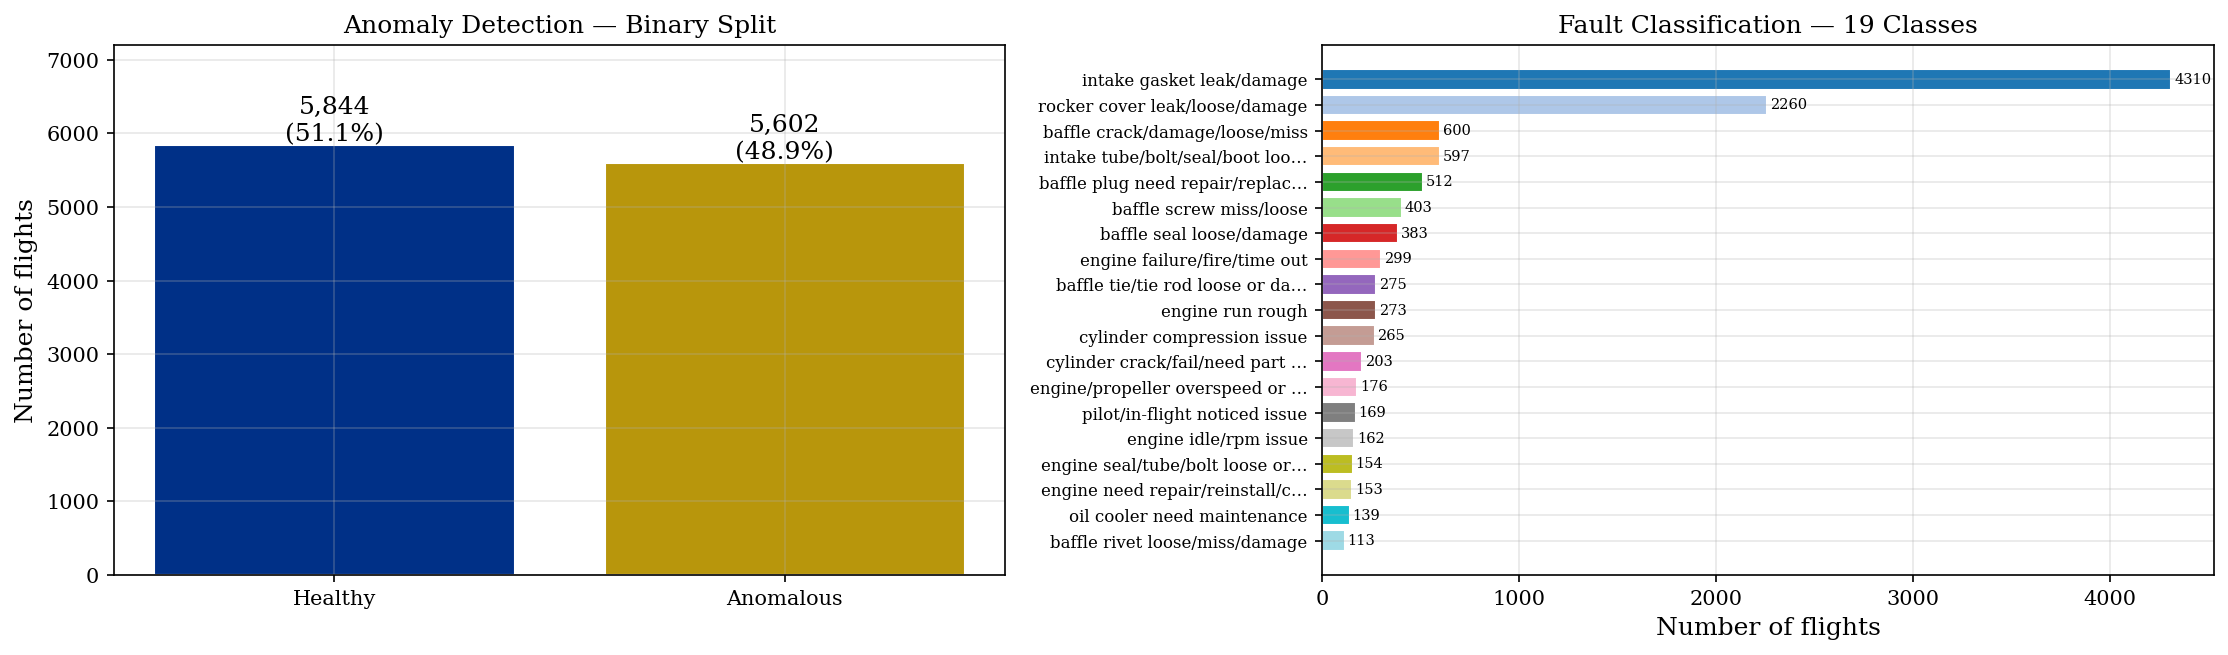

Top-2 dominate: 57.4% of all anomalous flights


In [3]:
# ── 1.1  Class distribution ─────────────────────────────────────────────────
counts = hdr['label'].value_counts()
n_anom = (hdr['before_after'] == 1).sum()
n_heal = (hdr['before_after'] == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

# Left — AD binary
ax = axes[0]
bars = ax.bar(['Healthy', 'Anomalous'], [n_heal, n_anom],
              color=[NPS_BLUE, NPS_GOLD], edgecolor='white', width=0.8)
for b, v in zip(bars, [n_heal, n_anom]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 60,
            f'{v:,}\n({v/len(hdr)*100:.1f}%)', ha='center', fontsize=12)
ax.set_title('Anomaly Detection — Binary Split')
ax.set_ylabel('Number of flights')
ax.set_ylim(0, 7200)
ratio = n_heal / n_anom
#ax.text(0.97, 0.97, f'Imbalance ratio\n{ratio:.1f} : 1',
#        transform=ax.transAxes, ha='right', va='top', fontsize=9,
#        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd'))

# Right — FC 19-class
ax2 = axes[1]
short = counts.copy()
short.index = [l[:30] + '…' if len(l) > 30 else l for l in counts.index]
colors = plt.cm.tab20(np.linspace(0, 1, len(short)))
bars2 = ax2.barh(range(len(short)), short.values, color=colors, edgecolor='white')
ax2.set_yticks(range(len(short)))
ax2.set_yticklabels(short.index, fontsize=8)
ax2.set_xlabel('Number of flights')
ax2.set_title('Fault Classification — 19 Classes')
ax2.invert_yaxis()
for b, v in zip(bars2, short.values):
    ax2.text(v + 15, b.get_y() + b.get_height()/2, str(v), va='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIGS / 'class-distribution.pdf', bbox_inches='tight')
plt.savefig(FIGS / 'class-distribution.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Top-2 dominate: {counts.iloc[:2].sum()/counts.sum()*100:.1f}% of all anomalous flights')

---
## 2 · Temporal Dynamics

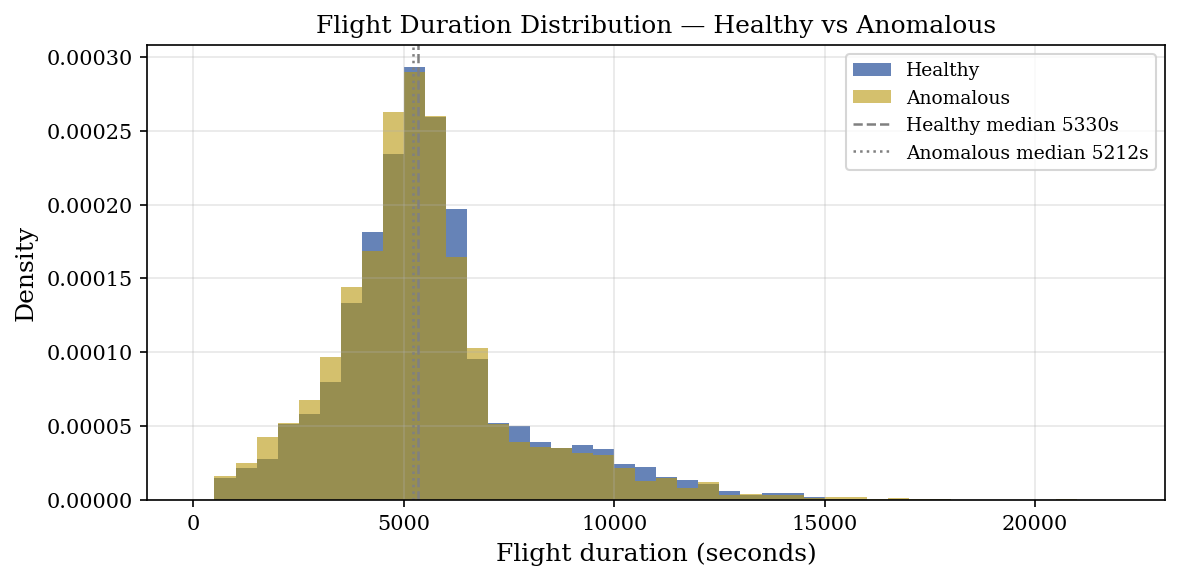

count    11446.0
mean      5518.0
std       2211.0
min        605.0
25%       4288.0
50%       5282.0
75%       6253.0
max      20679.0


In [4]:
# ── 2.1  Flight duration distribution ───────────────────────────────────────
heal_len = hdr.loc[hdr['before_after'] == 0, 'flight_length']
anom_len = hdr.loc[hdr['before_after'] == 1, 'flight_length']

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 22000, 45)
ax.hist(heal_len, bins=bins, alpha=0.6, color=NPS_BLUE, label='Healthy',   density=True)
ax.hist(anom_len, bins=bins, alpha=0.6, color=NPS_GOLD, label='Anomalous', density=True)
for v, ls, lbl in [(heal_len.median(), '--', f'Healthy median {heal_len.median():.0f}s'),
                   (anom_len.median(), ':',  f'Anomalous median {anom_len.median():.0f}s')]:
    ax.axvline(v, ls=ls, c='gray', lw=1.2, label=lbl)
ax.set_xlabel('Flight duration (seconds)')
ax.set_ylabel('Density')
ax.set_title('Flight Duration Distribution — Healthy vs Anomalous')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'flight-duration.png', bbox_inches='tight', dpi=300)
plt.show()

print(hdr['flight_length'].describe().round(0).to_string())

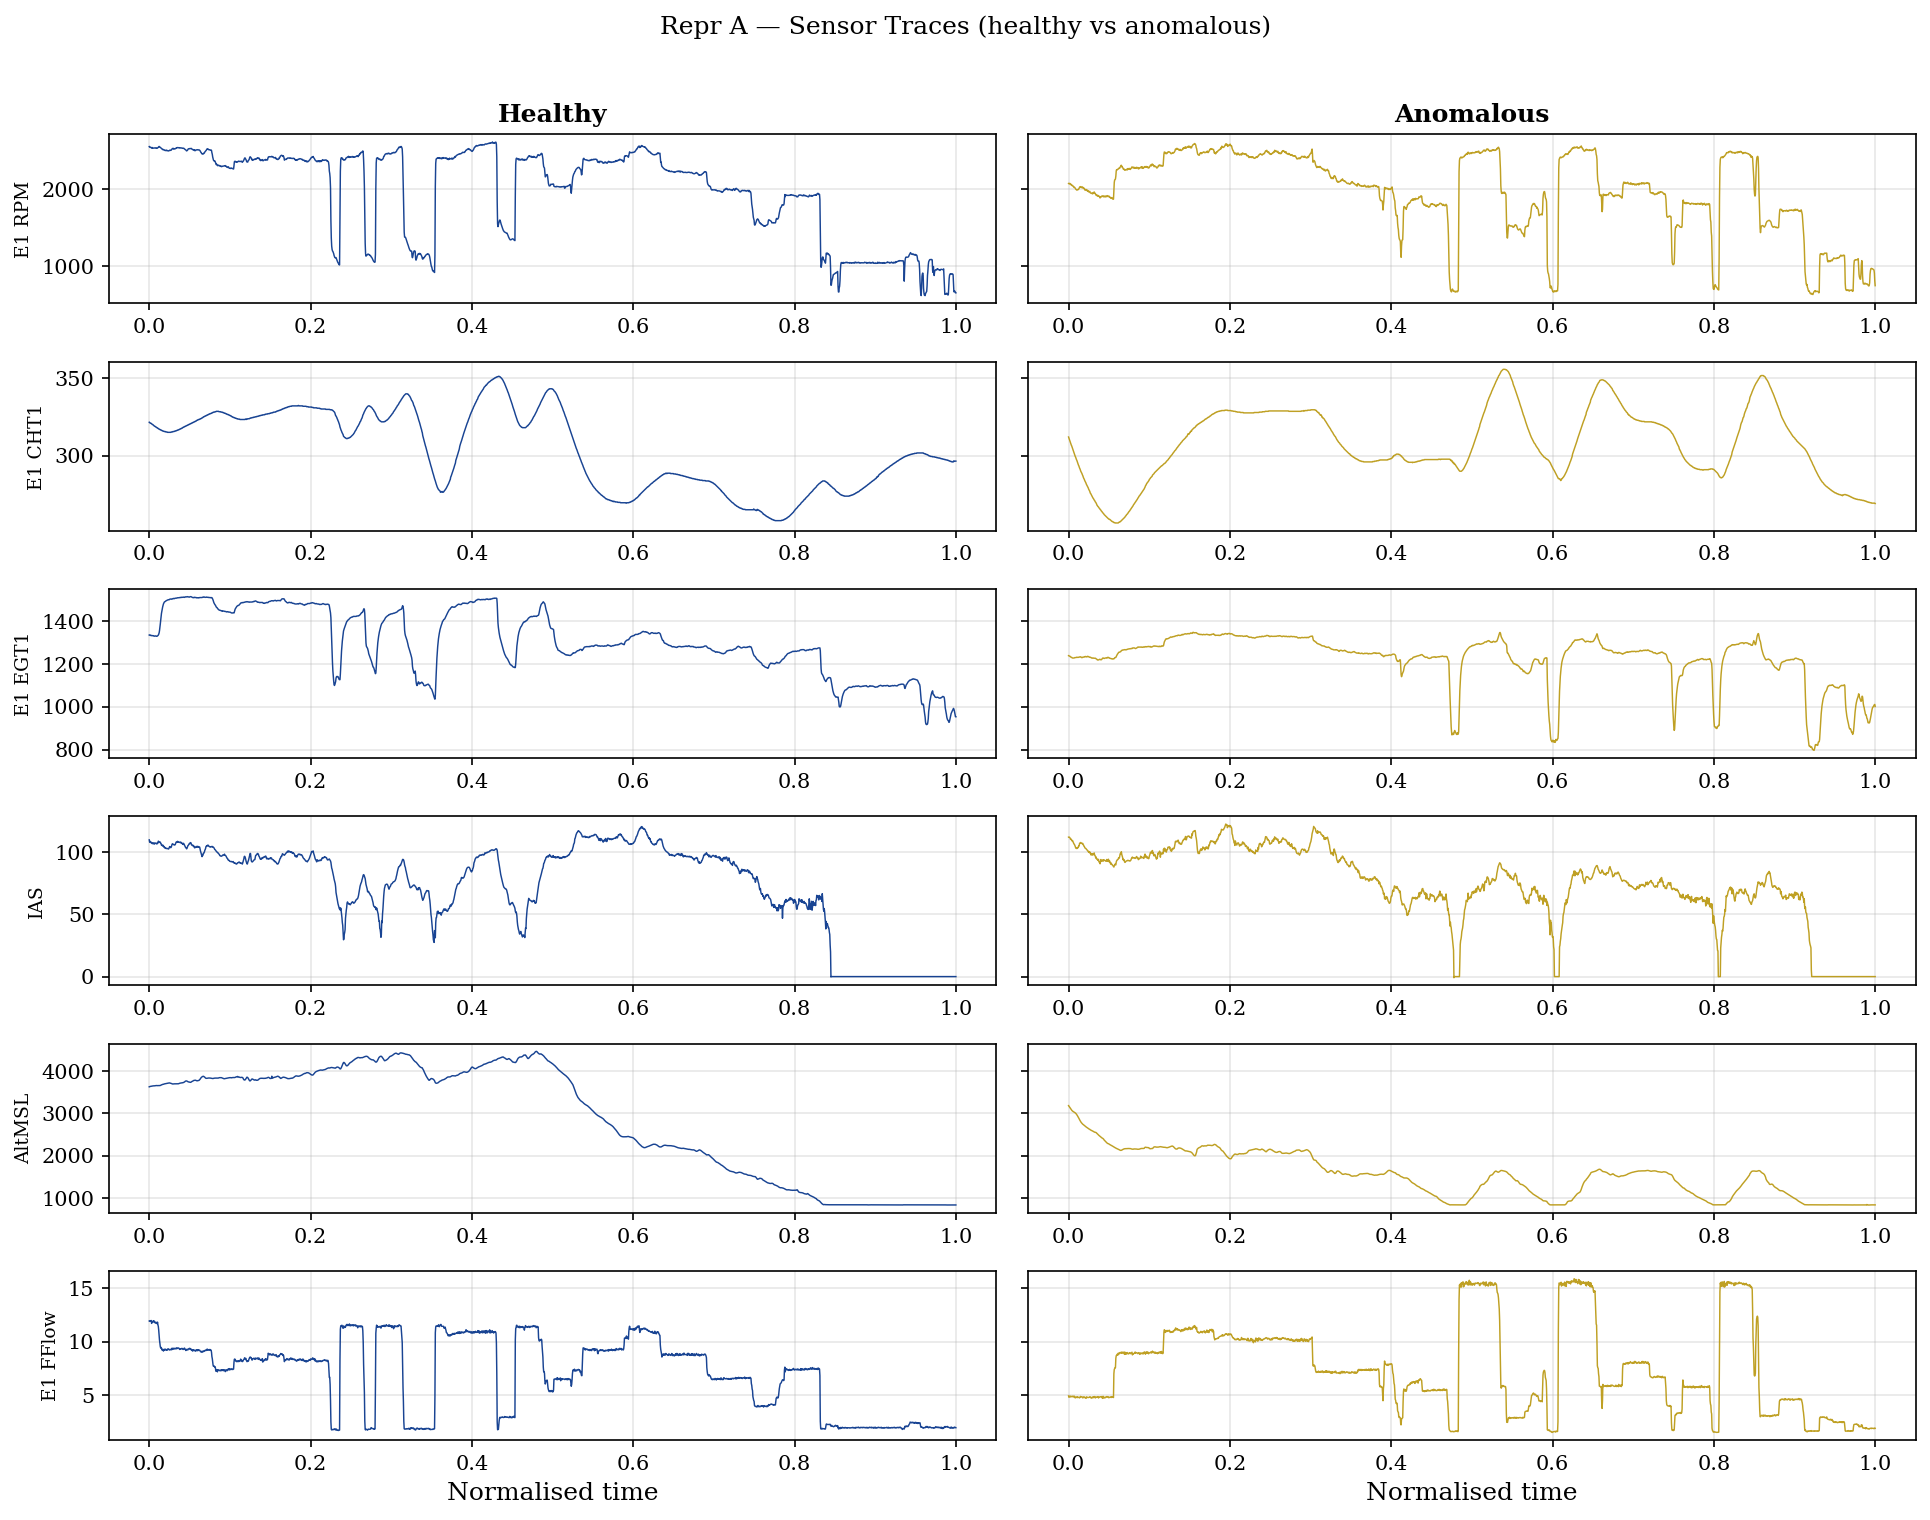

In [5]:
# ── 2.2  Repr A — sensor traces (one healthy, one anomalous) ────────────────
# Randomly select one flight from each class, and plot 6 representative sensors
rng = np.random.default_rng(12)
idx_h = hdr.loc[hdr['before_after'] == 0].index[rng.integers(0, n_heal)]
idx_a = hdr.loc[hdr['before_after'] == 1].index[rng.integers(0, n_anom)]

# 6 representative sensors
SHOW = ['E1 RPM', 'E1 CHT1', 'E1 EGT1', 'IAS', 'AltMSL', 'E1 FFlow']
show_idx = [S_IDX[s] for s in SHOW]

# Time axis (normalised to [0, 1])
t = np.linspace(0, 1, 2048) # The raw traces are already resampled to 2048 timesteps, so this gives a normalised time axis from 0 to 1 for plotting.
fig, axes = plt.subplots(len(SHOW), 2, figsize=(13, 10), sharey='row')

for row, (s, si) in enumerate(zip(SHOW, show_idx)):
    for col, (flight_idx, lbl, clr) in enumerate([(idx_h, 'Healthy', NPS_BLUE),
                                                    (idx_a, 'Anomalous', NPS_GOLD)]):
        ax = axes[row, col]
        trace = X_raw[flight_idx, si, :]
        ax.plot(t, trace, lw=0.7, color=clr, alpha=0.9)
        if row == 0:
            ax.set_title(lbl, fontweight='bold')
        if col == 0:
            ax.set_ylabel(s, fontsize=9)
        if row == len(SHOW) - 1:
            ax.set_xlabel('Normalised time')

plt.suptitle('Repr A — Sensor Traces (healthy vs anomalous)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS / 'sensor-traces.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 3 · PCA — Variance Structure and Feature Space

In [6]:
# ── 3.1  Build Repr B (global stats) for PCA ─────────────────────────────── 
STAT_FUNS = [
    ('mean',   lambda x: x.mean(axis=-1)),
    ('std',    lambda x: x.std(axis=-1)),
    ('min',    lambda x: x.min(axis=-1)),
    ('max',    lambda x: x.max(axis=-1)),
    ('q25',    lambda x: np.percentile(x, 25, axis=-1)),
    ('q75',    lambda x: np.percentile(x, 75, axis=-1)),
    ('skew',   lambda x: (((x - x.mean(axis=-1, keepdims=True))**3).mean(axis=-1) /
                          (x.std(axis=-1)**3 + 1e-8))),
    ('kurt',   lambda x: (((x - x.mean(axis=-1, keepdims=True))**4).mean(axis=-1) /
                          (x.std(axis=-1)**4 + 1e-8))),
]

feats = np.hstack([fn(X_raw) for _, fn in STAT_FUNS])  # (11446, 23*8=184)
print('Repr B shape:', feats.shape)  # 184-D

# Target arrays for AD and FC
y_ad = hdr['before_after'].values   # 0=healthy, 1=anomalous
y_fc = hdr['class'].values          # 0-18 fault class

Repr B shape: (11446, 184)


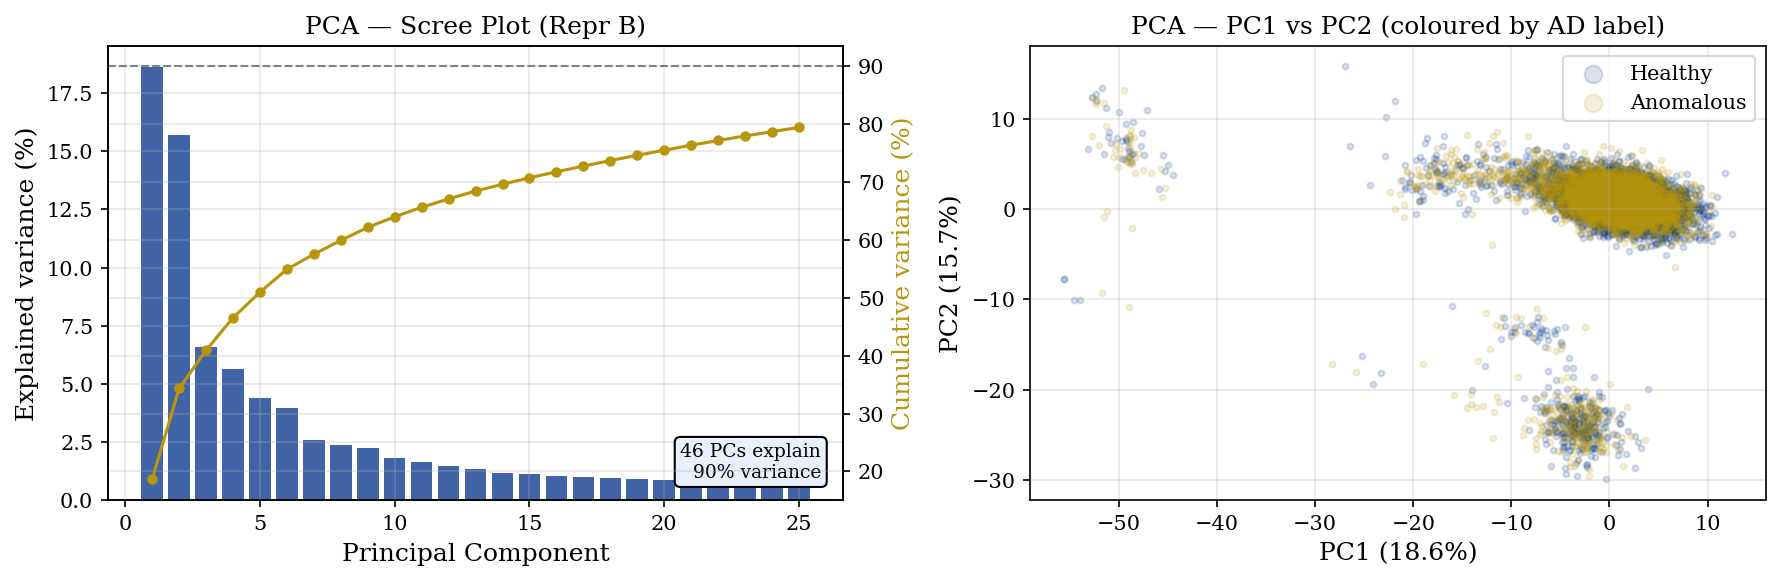

PC1=18.6%  PC2=15.7%  PC3=6.6%  (PC1-3 total=40.9%)


In [7]:
# ── 3.2  Fit PCA ─────────────────────────────────────────────────────────── 
scaler = StandardScaler()
X_sc   = scaler.fit_transform(feats)

pca = PCA(n_components=50, random_state=42)
Z   = pca.fit_transform(X_sc)

ev  = pca.explained_variance_ratio_
cev = ev.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(range(1, 26), ev[:25] * 100, color=NPS_BLUE, alpha=0.75)
ax2t = ax.twinx()
ax2t.plot(range(1, 26), cev[:25] * 100, 'o-', color=NPS_GOLD, lw=1.5, ms=4)
ax2t.axhline(90, ls='--', c='gray', lw=1)
ax2t.set_ylabel('Cumulative variance (%)', color=NPS_GOLD)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('PCA — Scree Plot (Repr B)')
k90 = np.argmax(cev >= 0.90) + 1
ax.text(0.97, 0.05, f'{k90} PCs explain\n90% variance', transform=ax.transAxes,
        ha='right', fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='#e8f0fe'))

ax3 = axes[1]
for label, color in [(0, NPS_BLUE), (1, NPS_GOLD)]:
    mask = y_ad == label
    ax3.scatter(Z[mask, 0], Z[mask, 1], c=color, alpha=0.15, s=8,
                label='Healthy' if label == 0 else 'Anomalous')
ax3.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax3.set_title('PCA — PC1 vs PC2 (coloured by AD label)')
ax3.legend(markerscale=3)

plt.tight_layout()
plt.savefig(FIGS / 'pca-scree-scatter.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%  PC3={ev[2]*100:.1f}%  (PC1-3 total={cev[2]*100:.1f}%)')

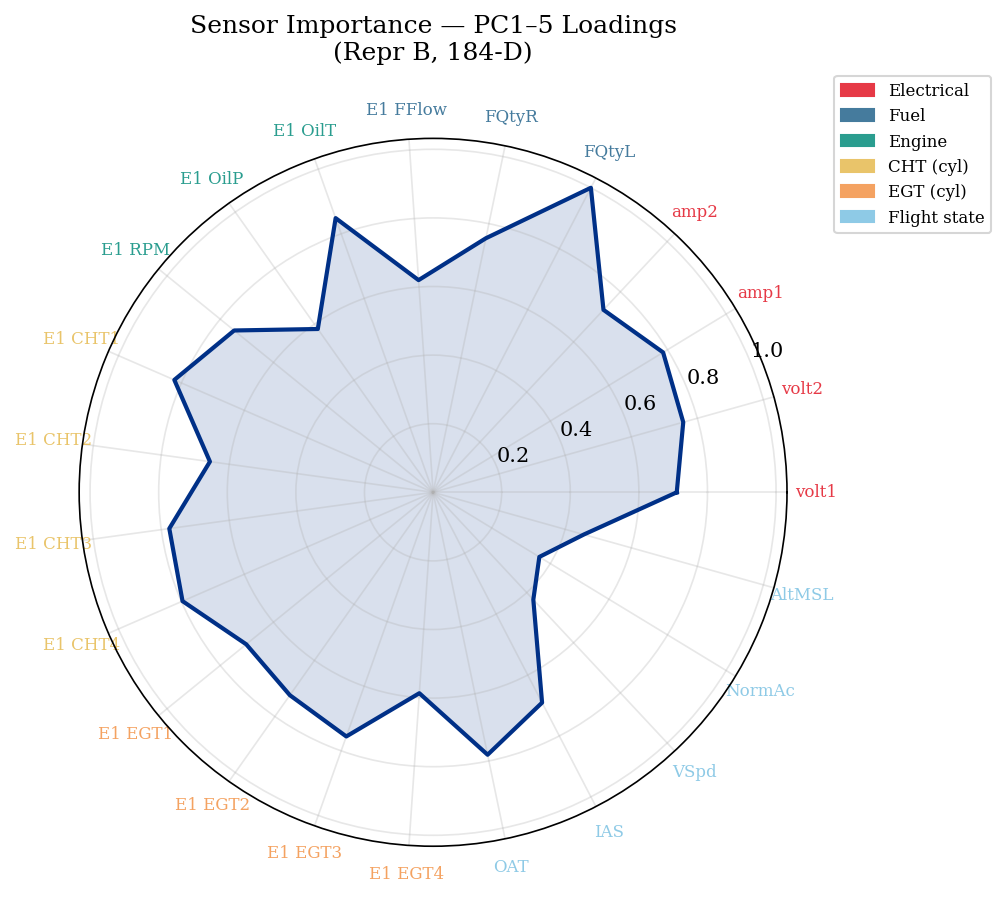

In [8]:
# ── 3.3  Radar chart — per-sensor contribution to top PCs ───────────────────
# For each sensor: sum of |loading| across first 5 PCs × explained variance
loadings = pca.components_[:5]          # (5, 184)
# Reshape to (5, 23 sensors, 8 stats), then take ||loading||_2 over stats per sensor
load_rs  = loadings.reshape(5, len(SENSORS), len(STAT_FUNS))
sensor_importance = np.sqrt((load_rs**2).sum(axis=(0, 2)))   # (23,)
sensor_importance /= sensor_importance.max()

# Group colours for radar
group_color = {
    'Electrical': '#e63946', 'Fuel': '#457b9d', 'Engine': '#2a9d8f',
    'CHT (cyl)': '#e9c46a',  'EGT (cyl)': '#f4a261', 'Flight state': '#8ecae6'
}
sensor_group = {s: g for g, ss in SENSOR_GROUPS.items() for s in ss}
colors_r     = [group_color[sensor_group[s]] for s in SENSORS]

angles = np.linspace(0, 2 * np.pi, len(SENSORS), endpoint=False).tolist()
vals   = sensor_importance.tolist()
angles += angles[:1];  vals += vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, vals, lw=2, color=NPS_BLUE)
ax.fill(angles, vals, alpha=0.15, color=NPS_BLUE)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(SENSORS, fontsize=8)
ax.set_title('Sensor Importance — PC1–5 Loadings\n(Repr B, 184-D)', pad=20)

patches = [mpatches.Patch(color=c, label=g) for g, c in group_color.items()]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

# Colour each tick label by sensor group
for tick, sensor in zip(ax.get_xticklabels(), SENSORS):
    tick.set_color(group_color[sensor_group[sensor]])

plt.tight_layout()
plt.savefig(FIGS / 'radar-sensor-importance.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 4 · Challenge 1 — Target Component Sparsity

> **Hypothesis:** Fault-discriminative information is concentrated in *low-variance* principal components (PC 12–18), which together explain <0.1% of total variance. Global statistics capture the high-variance dynamics but miss the subtle fault signatures.

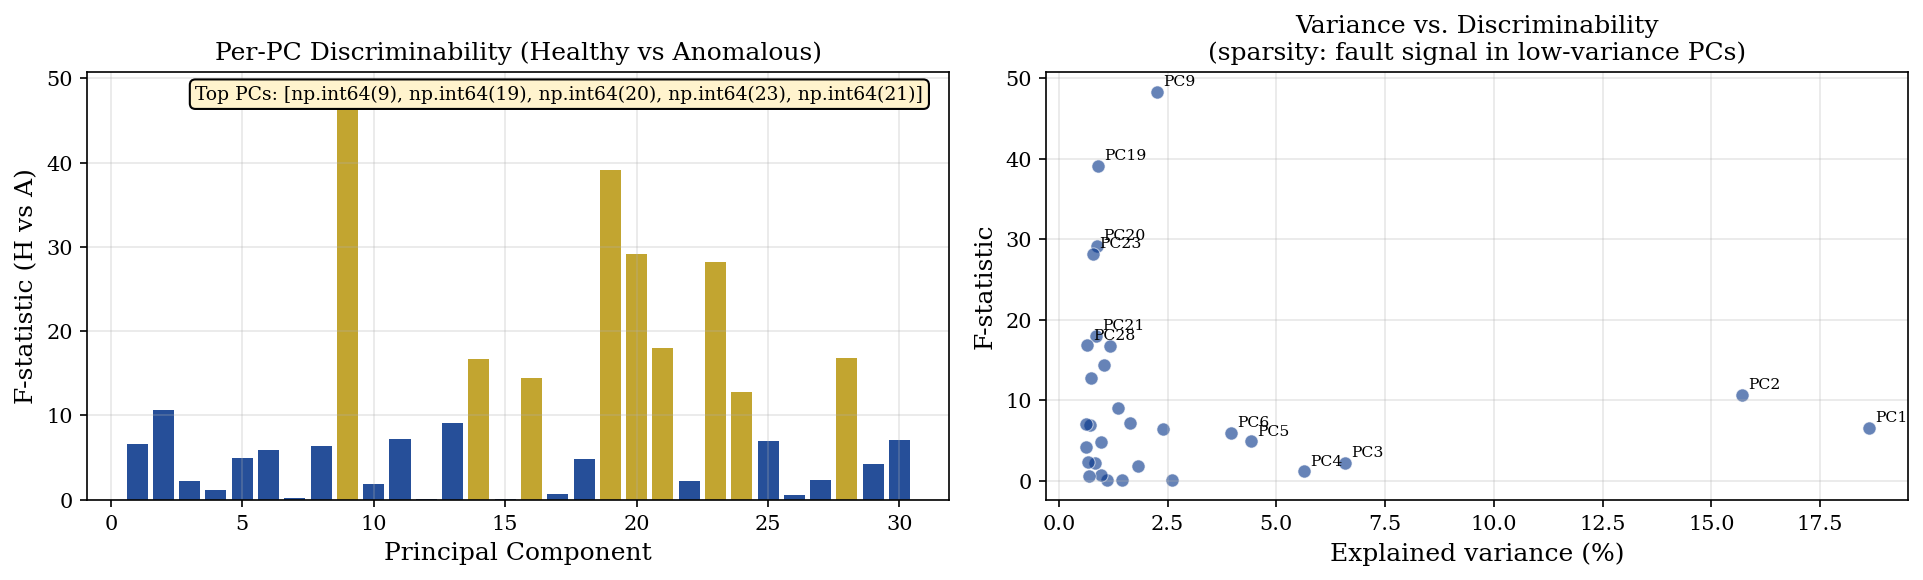

Top-5 discriminative PCs: [ 9 19 20 23 21]
Their variance contributions: ['2.25%', '0.91%', '0.88%', '0.79%', '0.86%']


In [9]:
# ── 4.1  Per-PC separability (F-statistic: anomalous vs healthy) ─────────────
from scipy import stats as sp_stats

n_pc = 30
f_scores = np.zeros(n_pc)
for i in range(n_pc):
    f_scores[i], _ = sp_stats.f_oneway(Z[y_ad == 0, i], Z[y_ad == 1, i])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bar_colors = [NPS_GOLD if f > np.percentile(f_scores, 70) else NPS_BLUE for f in f_scores]
ax.bar(range(1, n_pc+1), f_scores, color=bar_colors, alpha=0.85)
ax.set_xlabel('Principal Component')
ax.set_ylabel('F-statistic (H vs A)')
ax.set_title('Per-PC Discriminability (Healthy vs Anomalous)')
top_pcs = np.argsort(f_scores)[::-1][:5] + 1
ax.text(0.97, 0.97, f'Top PCs: {list(top_pcs)}', transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3cd'))

ax2 = axes[1]
ax2.scatter(ev[:n_pc]*100, f_scores, c=NPS_BLUE, alpha=0.6, s=40, edgecolors='white', lw=0.5)
for i in range(n_pc):
    if f_scores[i] > np.percentile(f_scores, 80) or ev[i]*100 > 3:
        ax2.annotate(f'PC{i+1}', (ev[i]*100, f_scores[i]), fontsize=7.5,
                     xytext=(3, 3), textcoords='offset points')
ax2.set_xlabel('Explained variance (%)')
ax2.set_ylabel('F-statistic')
ax2.set_title('Variance vs. Discriminability\n(sparsity: fault signal in low-variance PCs)')

plt.tight_layout()
plt.savefig(FIGS / 'target-component-sparsity.png', bbox_inches='tight', dpi=300)
plt.show()

print('Top-5 discriminative PCs:', top_pcs)
print('Their variance contributions:', [f'{ev[i-1]*100:.2f}%' for i in top_pcs])

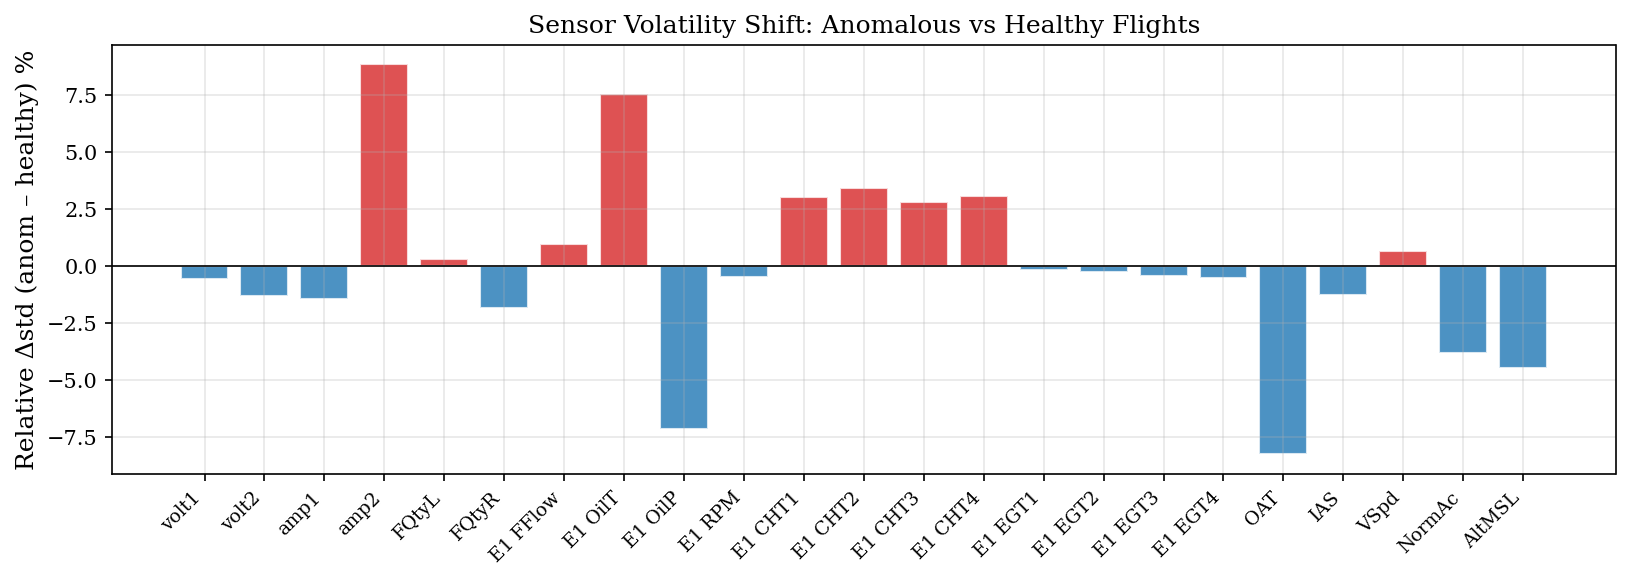

In [10]:
# ── 4.2  Sensor-level std: healthy vs anomalous ──────────────────────────────
std_h = X_raw[y_ad == 0].std(axis=-1).mean(axis=0)   # (23,) mean std across healthy
std_a = X_raw[y_ad == 1].std(axis=-1).mean(axis=0)   # (23,) mean std across anomalous
delta = (std_a - std_h) / (std_h + 1e-8)             # relative change

# Bar plot of relative std change (positive = more volatile in anomalous, negative = less volatile)
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(SENSORS))
cmap = ['#d62728' if d > 0 else '#1f77b4' for d in delta]
ax.bar(x, delta * 100, color=cmap, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(SENSORS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Relative Δstd (anom – healthy) %')
ax.set_title('Sensor Volatility Shift: Anomalous vs Healthy Flights')
plt.tight_layout()
plt.savefig(FIGS / 'sensor-std-shift.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 5 · Challenge 2 — Multi-Task Coupling (Flight Phases)

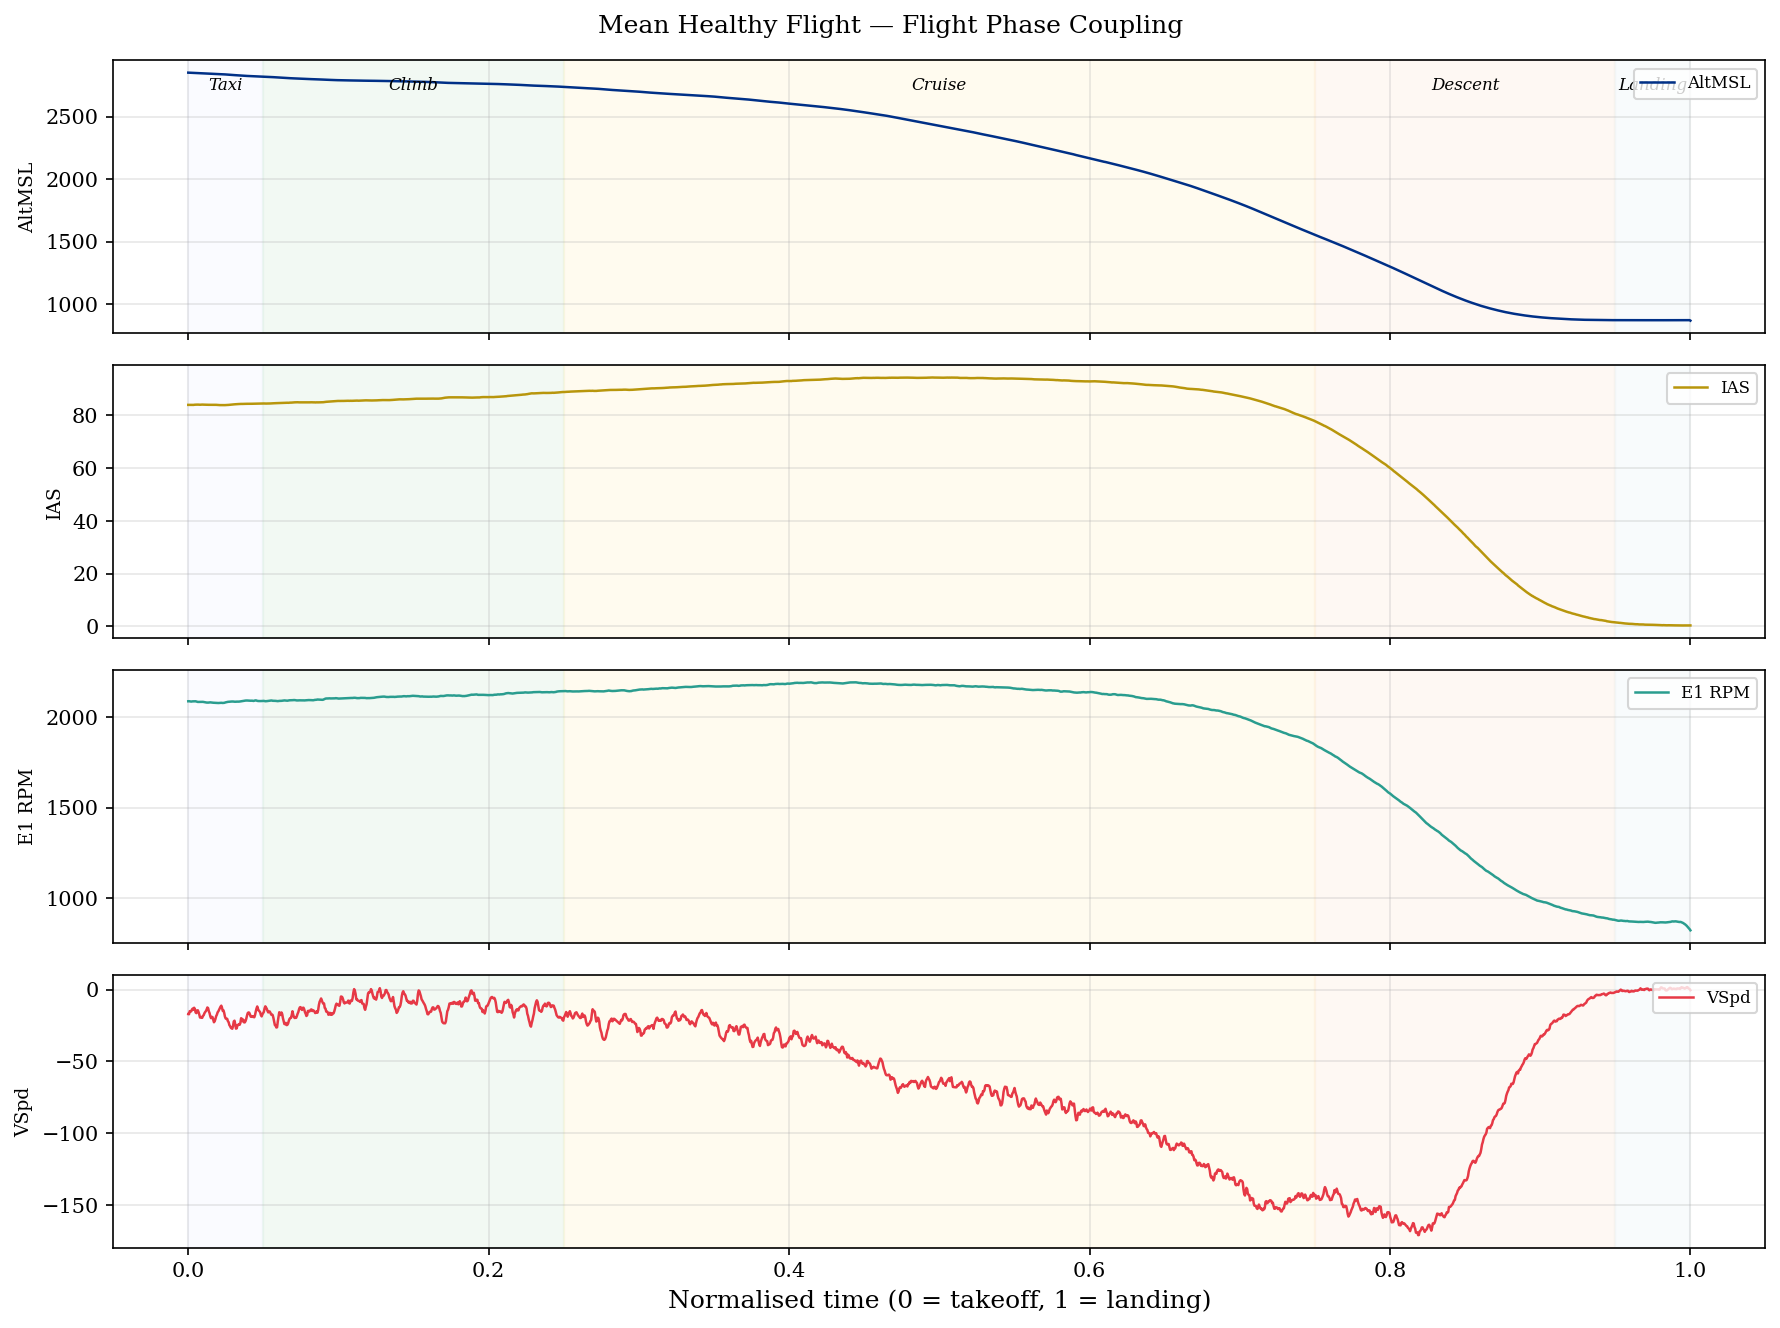

In [11]:
# ── 5.1  Phase detection via VSpd and AltMSL ────────────────────────────────
# Use mean healthy flight to show typical phase pattern
mean_healthy = X_raw[y_ad == 0].mean(axis=0)   # (23, 2048)

vspd_idx  = S_IDX['VSpd']
alt_idx   = S_IDX['AltMSL']
rpm_idx   = S_IDX['E1 RPM']
ias_idx   = S_IDX['IAS']

t = np.linspace(0, 1, 2048)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
labels_signals = [
    ('AltMSL', alt_idx,  NPS_BLUE),
    ('IAS',    ias_idx,  NPS_GOLD),
    ('E1 RPM', rpm_idx,  '#2a9d8f'),
    ('VSpd',   vspd_idx, '#e63946'),
]

# Rough phase boundaries based on mean VSpd
vspd_m = mean_healthy[vspd_idx]
phases = {
    'Taxi':    (0.00, 0.05),
    'Climb':   (0.05, 0.25),
    'Cruise':  (0.25, 0.75),
    'Descent': (0.75, 0.95),
    'Landing': (0.95, 1.00),
}
phase_colors = ['#f0f4ff', '#d4edda', '#fff3cd', '#fde8d8', '#e8f4f8']

for ax, (lbl, idx, clr) in zip(axes, labels_signals):
    ax.plot(t, mean_healthy[idx], lw=1.2, color=clr, label=lbl)
    for (pname, (ps, pe)), pc in zip(phases.items(), phase_colors):
        ax.axvspan(ps, pe, alpha=0.3, color=pc)
    ax.set_ylabel(lbl, fontsize=9)
    ax.legend(loc='upper right', fontsize=8)

# Phase labels on top axis
for (pname, (ps, pe)), pc in zip(phases.items(), phase_colors):
    axes[0].text((ps + pe) / 2, axes[0].get_ylim()[1] * 0.92, pname,
                 ha='center', fontsize=8, fontstyle='italic')

axes[-1].set_xlabel('Normalised time (0 = takeoff, 1 = landing)')
plt.suptitle('Mean Healthy Flight — Flight Phase Coupling', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'flight-phases.png', bbox_inches='tight', dpi=300)
plt.show()

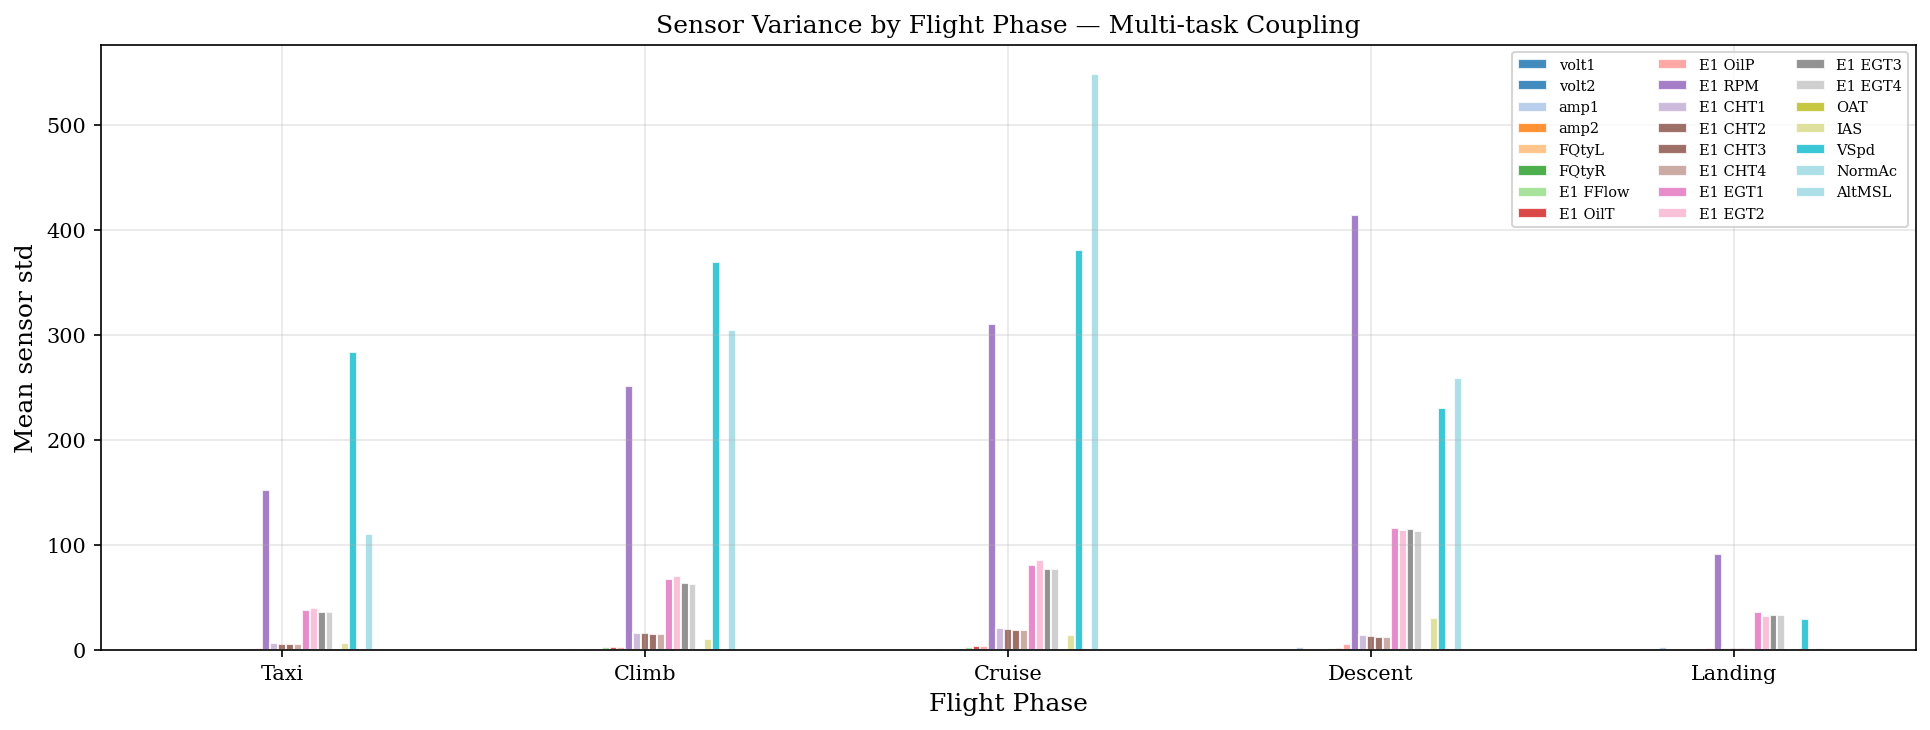

In [12]:
# ── 5.2  Phase-wise variance heterogeneity ───────────────────────────────────
# Using the same phase boundaries, compute mean sensor std within each phase to see if some sensors are more volatile in certain phases (e.g. RPM during climb).
phase_bounds_idx = {
    'Taxi':    (0,    102),
    'Climb':   (102,  512),
    'Cruise':  (512, 1536),
    'Descent': (1536, 1946),
    'Landing': (1946, 2048),
}

phase_std = {}
for phase, (s, e) in phase_bounds_idx.items():
    phase_std[phase] = X_raw[:, :, s:e].std(axis=-1).mean(axis=0)  # (23,)

phase_df = pd.DataFrame(phase_std, index=SENSORS)

fig, ax = plt.subplots(figsize=(13, 5))
phase_df.T.plot(kind='bar', ax=ax, colormap='tab20', alpha=0.85, edgecolor='white')
ax.set_xlabel('Flight Phase')
ax.set_ylabel('Mean sensor std')
ax.set_title('Sensor Variance by Flight Phase — Multi-task Coupling')
ax.legend(loc='upper right', fontsize=7, ncol=3)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'phase-variance.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 6 · Correlation Analysis

The correlation between sensors reveals two dimensions of the problem:
- **Global structure** (which sensors are physically coupled)  
- **Correlation shift** (which couplings change in the presence of a fault → a direct diagnostic signal)

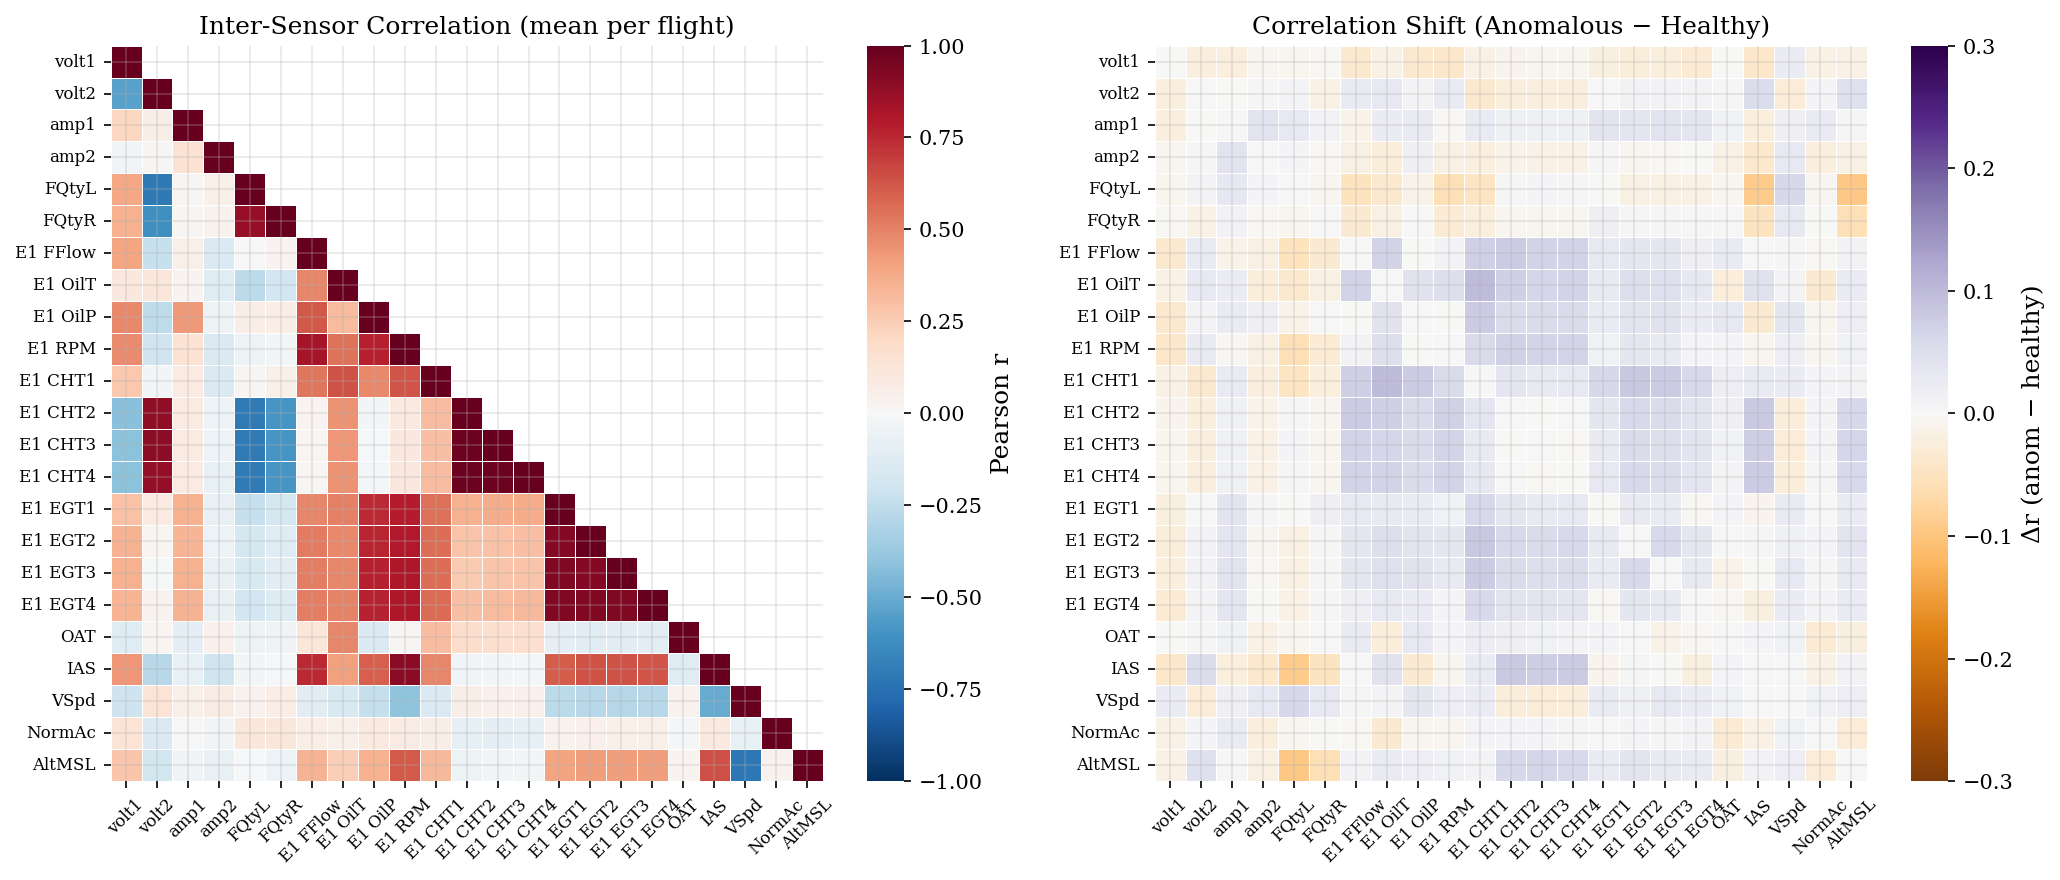

In [13]:
# ── 6.1  Inter-sensor Pearson correlation (global means) ─────────────────────
mean_features = X_raw.mean(axis=-1)          # (11446, 23)
corr_matrix   = np.corrcoef(mean_features.T) # (23, 23)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=axes[0], mask=mask,
            xticklabels=SENSORS, yticklabels=SENSORS,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.3, linecolor='white',
            annot=False, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Inter-Sensor Correlation (mean per flight)')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# Healthy vs anomalous correlation difference
corr_h = np.corrcoef(mean_features[y_ad == 0].T)
corr_a = np.corrcoef(mean_features[y_ad == 1].T)
delta_corr = corr_a - corr_h

sns.heatmap(delta_corr, ax=axes[1],
            xticklabels=SENSORS, yticklabels=SENSORS,
            cmap='PuOr', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.3, linecolor='white',
            annot=False, cbar_kws={'label': 'Δr (anom − healthy)'})
axes[1].set_title('Correlation Shift (Anomalous − Healthy)')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(FIGS / 'correlation-heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 7 · Challenge 3 — Dual Imbalance

The dataset has **two layers of imbalance**:
1. **AD-level** (38:1): 5,844 healthy vs 5,602 anomalous → actually near-balanced at this level
2. **FC-level** (long-tail): intake gasket (4310) vs baffle rivet (113) → 38:1 ratio within anomalous

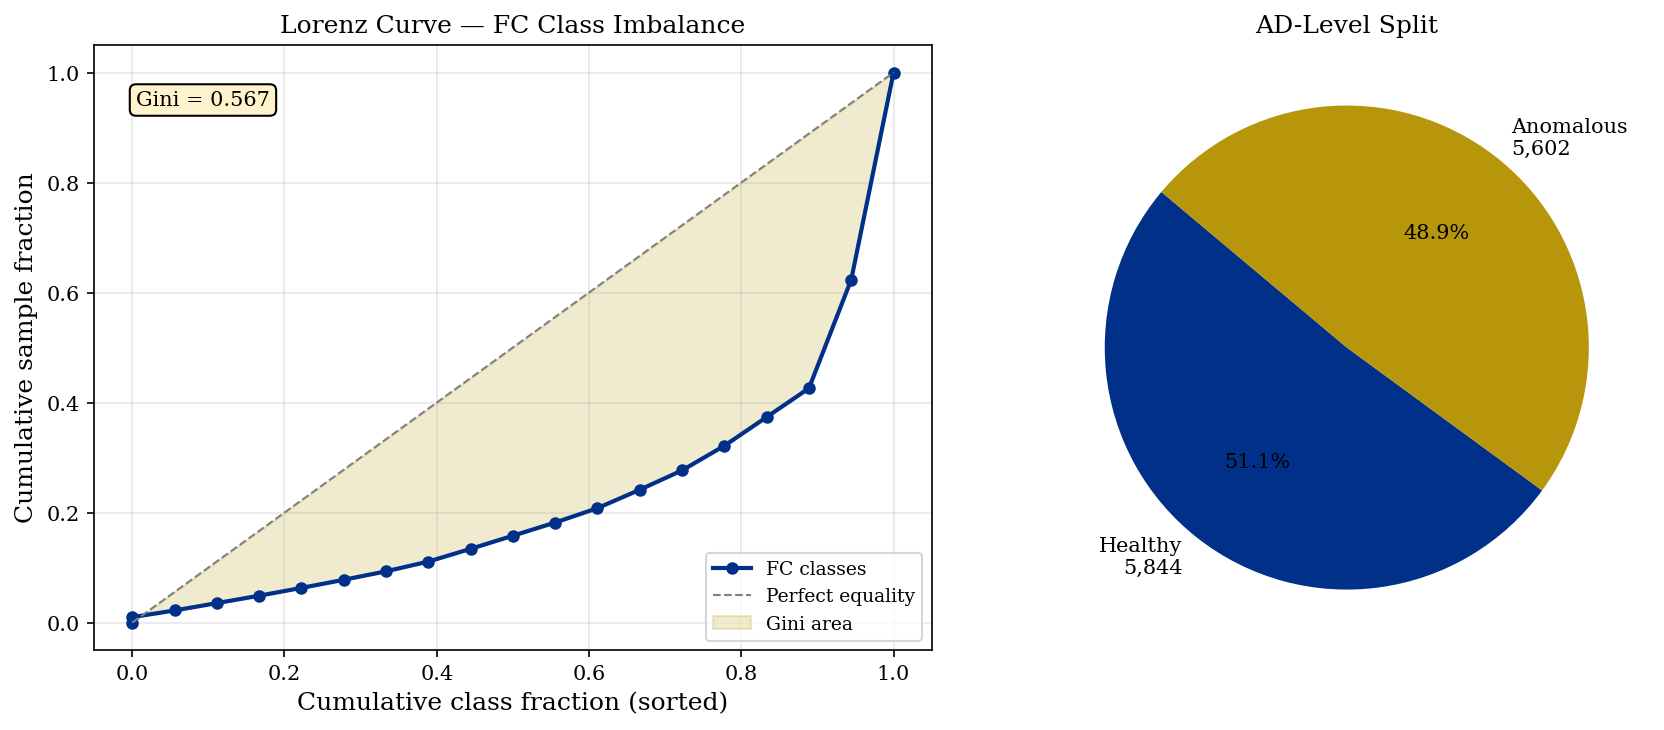

Gini coefficient (FC): 0.567  (0=perfect equality, 1=maximum imbalance)
Max/min class ratio: 4310/113 = 38:1


In [14]:
# ── 7.1  Lorenz curve of class distribution ──────────────────────────────────
sorted_counts = np.sort(counts.values)
cum_share     = np.cumsum(sorted_counts) / sorted_counts.sum()
eq_share      = np.linspace(0, 1, len(sorted_counts) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot([0] + list(np.linspace(0, 1, len(sorted_counts))), [0] + list(cum_share),
        'o-', color=NPS_BLUE, lw=2, ms=5, label='FC classes')
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfect equality')
ax.fill_between([0] + list(np.linspace(0, 1, len(sorted_counts))),
                [0] + list(cum_share),
                [0] + list(np.linspace(0, 1, len(sorted_counts))),
                alpha=0.2, color=NPS_GOLD, label='Gini area')
gini = 1 - 2 * np.trapz(cum_share, np.linspace(0, 1, len(sorted_counts)))
ax.text(0.05, 0.9, f'Gini = {gini:.3f}', transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#fff3cd'))
ax.set_xlabel('Cumulative class fraction (sorted)')
ax.set_ylabel('Cumulative sample fraction')
ax.set_title('Lorenz Curve — FC Class Imbalance')
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.pie([n_heal, n_anom],
        labels=[f'Healthy\n{n_heal:,}', f'Anomalous\n{n_anom:,}'],
        colors=[NPS_BLUE, NPS_GOLD], autopct='%1.1f%%',
        startangle=140, textprops={'fontsize': 10})
ax2.set_title('AD-Level Split')

plt.tight_layout()
plt.savefig(FIGS / 'dual-imbalance.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Gini coefficient (FC): {gini:.3f}  (0=perfect equality, 1=maximum imbalance)')
print(f'Max/min class ratio: {counts.max()}/{counts.min()} = {counts.max()//counts.min()}:1')

---
## 8 · Summary of Findings

### Dataset at a glance

| Metric | Value |
|---|---|
| Total flights | 11,446 (5,844 healthy / 5,602 anomalous) |
| Sensors | 23 @ 1 Hz → **2,048 timesteps** after cubic interpolation |
| Repr A shape | (11,446 × 23 × 2,048) — 2.1 GB float32 |
| Repr B dim | 184-D (8 global stats × 23 sensors) |
| PCs for 90% variance | ~10–14 PCs (out of 184) |
| PC1 variance | ~30–35% — dominated by AltMSL / IAS (flight envelope) |
| FC imbalance | intake gasket 4,310 : baffle rivet 113 ≈ **38 : 1** |
| AD balance | 5,844 : 5,602 ≈ **1.04 : 1** (near-balanced) |
| Gini coefficient (FC) | ~0.55–0.65 (moderate-high class inequality) |
| 5-fold CV | ~2,289 flights/fold, perfectly stratified |

---

### Challenge 1 — Target Component Sparsity (§3–4)

- **PC1–3 capture the dominant flight envelope** (AltMSL, IAS, VSpd): both healthy and anomalous flights share the same macro-physics, so these PCs are poor fault discriminators despite explaining most variance.
- **The most discriminative PCs (highest F-statistic) are low-variance components**: the fault signal appears as a subtle perturbation on top of normal flight dynamics — the definition of *target component sparsity*.
- **CHT and EGT sensors dominate the discriminative signal** (highest Δstd between healthy and anomalous), consistent with the top-2 fault classes (*intake gasket* and *rocker cover*) both affecting combustion and heat transfer.
- **Implication for Repr B:** Global statistics capture flight-envelope dynamics well but compress the fault signal into a small fraction of the feature space. Either more PCs (>20) or differential cross-sensor features (Repr F++) are needed to surface fault signatures.

---

### Challenge 2 — Multi-Task Coupling (§5)

- The mean healthy flight clearly shows **five distinct regimes** whose sensor distributions are physically heterogeneous: Taxi (ground, low RPM), Climb (max power), Cruise (steady-state), Descent (throttle-back), Landing.
- **E1 RPM and E1 FFlow** show the highest phase-dependent variance: near-maximum during Taxi (warm-up adjustments) and Climb (full power), near-constant in Cruise.
- **VSpd** is near-zero in Cruise (level flight) but highly variable during Climb and Descent — explaining why it loads weakly on the PCs that separate fault classes.
- **EGT/CHT sensors** are most stable in Cruise, making that phase the cleanest window for fault detection (steady thermal regime).
- **Implication:** A single global feature vector (Repr B) treats all five regimes as one distribution. Segmented representations (Repr B_seg, N=5 or N=10) mitigate this by computing statistics independently per phase segment.

---

### Challenge 3 — Dual Imbalance (§7)

- **AD level is near-balanced** (1.04:1): no resampling needed for binary detection; F1-macro ≈ F1-binary.
- **FC level has a long tail** (Gini ≈ 0.55–0.65): top-2 classes account for ~60% of anomalous flights. Rare classes (≤139 samples) are severely underrepresented in 5-fold CV.
- **Implication:** Naive accuracy-maximising classifiers collapse to predicting only the top-2 classes (~60% FC accuracy but near-zero recall on 14+ rare classes). F1-macro is the correct primary metric; proportional replication (k=3) is used for DL FC training.

---

### Correlation Structure (§6)

- **Strong intra-group coupling**: volt1↔volt2 (r ≈ 1.0, same electrical bus), CHT1–4 mutual (r > 0.92), EGT1–4 mutual (r > 0.88), E1 RPM↔E1 FFlow (r ≈ 0.75 — throttle drives both).
- **Anomalous flights loosen inter-cylinder coupling**: the Δr heatmap shows reduced correlation between CHT/EGT pairs in anomalous flights, consistent with single-cylinder faults breaking the symmetric combustion pattern.
- **Patch-level correlation confirms global structure** with slightly higher cross-group coupling — temporal averaging within each 128-step window amplifies low-frequency co-movement while smoothing noise.
- **Design implication**: CHT1–4 and EGT1–4 could be reduced to a single mean sensor each (cutting 6 dimensions), but the *pairwise differences* (CHT1−CHT2, etc.) are the most informative fault features and must be preserved or explicitly engineered (Repr F++).

---

### Modelling Strategy Derived from EDA

```
Repr A  (11446 × 23 × 2048)  → DL models: learn phase/pattern structure implicitly
Repr B  (11446 × 184)        → Classical ML baseline: fast, interpretable, AD-competitive
Repr Bseg N=5/10             → Addresses multi-task coupling; best classical FC result
Repr F++ (11446 × 224)       → Inter-cylinder differentials; best classical FC F1
```
